In [ ]:
import os
import re
import math
import time
import json
import requests
import numpy as np
import pandas as pd
# from google import genai
# from google.genai import types
from google.colab import drive
from google.colab import userdata
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os
import time

# List of tickers to process
target_tickers_list = [
    "GM", "MPWR", "APTV", "QCOM", "F", "VTRS", "MTD", "TSLA", "ISRG", "MRK",
    "MU", "GLW", "PFE", "SMCI", "TECH", "AMAT", "DHR", "AMD", "KLAC", "ZTS",
    "AAPL", "MCHP", "NVDA", "LRCX", "ANET", "TDY", "CSCO", "ON", "TER", "WAT",
    "STLAM", "RACE", "SAP", "NOKIA", "LOGN", "NOVN", "STMMI", "ASML",
    "AMGN", "LLY", "ERICB", "MDT", "ABT"
]
# Convert to set for faster lookup and deduplication (MRK was listed twice)
target_tickers = set(target_tickers_list)

output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving filings for {len(target_tickers)} target companies to ./output/...")

# Combine dictionaries to process all relevant filings
# We handle cases where 'all_years_ten_k_dict' might not be defined yet
combined_filings = {}
if 'all_years_ten_k_dict' in globals():
    combined_filings = all_years_ten_k_dict.copy()
elif 'filtered_ten_k_dict' in globals():
    combined_filings = filtered_ten_k_dict.copy()
else:
    print("Warning: 'all_years_ten_k_dict' not found. Skipping domestic filings.")

# Merge foreign filings if available
if 'filtered_foreign_filings_dict' in globals():
    for company, filings in filtered_foreign_filings_dict.items():
        if company in combined_filings:
            # Append unique filings
            existing_accs = set(f[2] for f in combined_filings[company])
            for filing in filings:
                if filing[2] not in existing_accs:
                    combined_filings[company].append(filing)
        else:
            combined_filings[company] = filings
else:
    print("Warning: 'filtered_foreign_filings_dict' not found. Skipping foreign filings.")

companies_processed = 0

for company, filings in combined_filings.items():
    # Get basic info
    ticker = None
    cik = None

    if 'd_companies' in globals() and company in d_companies:
        info = d_companies[company]
        ticker = info.get('ticker', company)
        cik = info.get('cik')
    elif 'd_companies_foreign' in globals() and company in d_companies_foreign:
        info = d_companies_foreign[company]
        ticker = info.get('ticker', company)
        cik = info.get('cik')
    else:
        # Metadata not found, skip silently or print if important
        continue

    if not ticker or not cik:
        continue

    # Check if this company is in our target list
    # We normalize/sanitize the ticker just in case, but usually strict match works
    if ticker not in target_tickers:
        continue

    companies_processed += 1

    # Sanitize ticker for filename/folder
    safe_ticker = "".join([c for c in ticker if c.isalnum() or c in ('-', '_')]).strip()

    company_dir = os.path.join(output_dir, safe_ticker)
    if not os.path.exists(company_dir):
        os.makedirs(company_dir)

    print(f"Processing {safe_ticker}...")

    for filing in filings:
        form, date, acc, primary_doc = filing
        year = date[:4]

        # Create unique filename: Year_Form_Accession.txt
        filename = f"{year}_{form}_{acc}.txt"
        filepath = os.path.join(company_dir, filename)

        if os.path.exists(filepath):
            continue # Already downloaded

        text = get_filing_text(cik, acc, primary_doc)

        if text:
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
            # print(f"  Saved {safe_ticker}/{filename}")
        else:
            print(f"  Failed to download {safe_ticker}/{filename}")

        # Polite delay
        time.sleep(0.1)

print(f"Done saving filings. Processed {companies_processed} of {len(target_tickers)} target companies.")

Saving filings for 43 target companies to ./output/...
Processing LLY...
Processing MRK...
Processing AMGN...
Processing NOVN...
Processing ABT...
Processing ASML...
Processing SAP...
Processing ERICB...
Processing LOGN...
Processing NOKIA...
Processing STMMI...
Done saving filings. Processed 11 of 43 target companies.


In [ ]:
import requests
import time
import os

# 1. Build a consolidated Ticker -> CIK map from existing dictionaries
ticker_map = {}

# Helper to add from existing dicts
def add_to_map(source_dict):
    if source_dict:
        for name, info in source_dict.items():
            if 'ticker' in info and 'cik' in info:
                ticker_map[info['ticker']] = info['cik']

if 'd_companies' in globals():
    add_to_map(d_companies)
if 'd_companies_foreign' in globals():
    add_to_map(d_companies_foreign)

# 2. Update/Fallback with fresh SEC data for any missing tickers
sec_lookup_url = "https://www.sec.gov/files/company_tickers.json"
try:
    resp = requests.get(sec_lookup_url, headers=headers)
    if resp.status_code == 200:
        sec_data = resp.json()
        for entry in sec_data.values():
            ticker = entry['ticker']
            # Zero-pad CIK
            cik = str(entry['cik_str']).zfill(10)
            if ticker not in ticker_map:
                ticker_map[ticker] = cik
except Exception as e:
    print(f"Warning: Could not fetch fresh SEC ticker data: {e}")

# 3. Process the target_tickers_list directly
print(f"Processing explicit list of {len(target_tickers)} tickers...")

target_years_range = [str(y) for y in range(2014, 2015)]
processed_count = 0

for ticker in target_tickers:
    safe_ticker = "".join([c for c in ticker if c.isalnum() or c in ('-', '_')]).strip()

    # Lookup CIK
    cik = ticker_map.get(ticker)
    if not cik:
        print(f"Skipping {ticker}: CIK not found.")
        continue

    # Prepare output dir
    company_dir = os.path.join(output_dir, safe_ticker)
    if not os.path.exists(company_dir):
        os.makedirs(company_dir)

    print(f"Processing {ticker} (CIK: {cik})...")

    # Fetch filings metadata
    # We look for 10-K (domestic) and 20-F (foreign)
    filings = get_filings(cik, forms=['10-K', '20-F'])

    files_saved = 0
    for filing in filings:
        form, date, acc, primary_doc = filing
        year = date[:4]

        # Filter by year
        if year not in target_years_range:
            continue

        # Check if file already exists to avoid re-downloading
        filename = f"{year}_{form}_{acc}.txt"
        filepath = os.path.join(company_dir, filename)

        if os.path.exists(filepath):
            files_saved += 1
            continue

        # Download content
        text = get_filing_text(cik, acc, primary_doc)
        if text:
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
            files_saved += 1
        else:
            print(f"  Failed to download text for {filename}")

        # Rate limit
        time.sleep(0.1)

    print(f"  {files_saved} filings available/saved for {ticker}.")
    processed_count += 1
    time.sleep(0.1)

print(f"\nCompleted. Processed {processed_count} companies from the target list.")

Processing explicit list of 43 tickers...
Processing KLAC (CIK: 0000319201)...
  1 filings available/saved for KLAC.
Processing DHR (CIK: 0000313616)...
  1 filings available/saved for DHR.
Processing F (CIK: 0000037996)...
  1 filings available/saved for F.
Processing APTV (CIK: 0001521332)...
  1 filings available/saved for APTV.
Processing LOGN (CIK: 0001032975)...
  1 filings available/saved for LOGN.
Processing TECH (CIK: 0000842023)...
  1 filings available/saved for TECH.
Processing NOKIA (CIK: 0000924613)...
  1 filings available/saved for NOKIA.
Processing AMAT (CIK: 0000006951)...
  1 filings available/saved for AMAT.
Processing AAPL (CIK: 0000320193)...
  1 filings available/saved for AAPL.
Processing MCHP (CIK: 0000827054)...
  1 filings available/saved for MCHP.
Processing AMD (CIK: 0000002488)...
  1 filings available/saved for AMD.
Processing GM (CIK: 0001467858)...
  1 filings available/saved for GM.
Processing MU (CIK: 0000723125)...
  1 filings available/saved for MU.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
d_companies_foreign = {
    "argenx SE": {
        "ticker": "ARGX.BR",
        "exchange": "Euronext Brussels",
        "country": "Belgium"
    },
    "ASML Holding N.V.": {
        "ticker": "ASML.AS",
        "exchange": "Euronext Amsterdam",
        "country": "Netherlands"
    },
    "Bayer AG": {
        "ticker": "BAYN.DE",
        "exchange": "Xetra",
        "country": "Germany"
    },
    "Bayerische Motoren Werke AG": {
        "ticker": "BMW.DE",
        "exchange": "Xetra",
        "country": "Germany"
    },
    "EssilorLuxottica": {
        "ticker": "EL.PA",
        "exchange": "Euronext Paris",
        "country": "France"
    },
    "Infineon Technologies AG": {
        "ticker": "IFX.DE",
        "exchange": "Xetra",
        "country": "Germany"
    },
    "Mercedes-Benz Group AG": {
        "ticker": "MBG.DE",
        "exchange": "Xetra",
        "country": "Germany"
    },
    "Sanofi": {
        "ticker": "SAN.PA",
        "exchange": "Euronext Paris",
        "country": "France"
    },
    "SAP SE": {
        "ticker": "SAP.DE",
        "exchange": "Xetra",
        "country": "Germany"
    },
    "Volkswagen AG": {
        "ticker": "VOW.DE",
        "exchange": "Xetra",
        "country": "Germany"
    }
}

# Display the new dictionary
for k, v in d_companies_foreign.items():
    print(f"{k}: {v}")

argenx SE: {'ticker': 'ARGX.BR', 'exchange': 'Euronext Brussels', 'country': 'Belgium'}
ASML Holding N.V.: {'ticker': 'ASML.AS', 'exchange': 'Euronext Amsterdam', 'country': 'Netherlands'}
Bayer AG: {'ticker': 'BAYN.DE', 'exchange': 'Xetra', 'country': 'Germany'}
Bayerische Motoren Werke AG: {'ticker': 'BMW.DE', 'exchange': 'Xetra', 'country': 'Germany'}
EssilorLuxottica: {'ticker': 'EL.PA', 'exchange': 'Euronext Paris', 'country': 'France'}
Infineon Technologies AG: {'ticker': 'IFX.DE', 'exchange': 'Xetra', 'country': 'Germany'}
Mercedes-Benz Group AG: {'ticker': 'MBG.DE', 'exchange': 'Xetra', 'country': 'Germany'}
Sanofi: {'ticker': 'SAN.PA', 'exchange': 'Euronext Paris', 'country': 'France'}
SAP SE: {'ticker': 'SAP.DE', 'exchange': 'Xetra', 'country': 'Germany'}
Volkswagen AG: {'ticker': 'VOW.DE', 'exchange': 'Xetra', 'country': 'Germany'}


In [ ]:
headers = {"User-Agent": "Name Name name@gmail.com"}

def get_filings(cik, forms=['10-K', '10-Q', '20-F']):
    if not cik:
        return []
    # API URL uses padded CIK
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"

    try:
        data = requests.get(url, headers=headers).json()

        all_filings_data = [data["filings"]["recent"]]

        if "files" in data["filings"]:
            for file_info in data["filings"]["files"]:
                file_url = f"https://data.sec.gov/submissions/{file_info['name']}"
                all_filings_data.append(requests.get(file_url, headers=headers).json())

        target_filings = []
        for filings in all_filings_data:
            # We need primaryDocument to construct the URL
            if "primaryDocument" not in filings:
                 continue

            for form, date, acc, primary_doc in zip(
                filings["form"],
                filings["filingDate"],
                filings["accessionNumber"],
                filings["primaryDocument"]
            ):
                if form in forms:
                    # Return metadata including primaryDocument
                    target_filings.append((form, date, acc, primary_doc))

        return target_filings
    except Exception as e:
        print(f"not found or error: {e}")
        return []

def get_filing_text(cik, accession_number, primary_document):
    """
    Fetches the text content of a filing given the CIK, Accession Number, and Primary Document filename.
    """
    try:
        # Archives URL uses integer CIK (no leading zeros)
        cik_int = int(cik)
        acc_no_dash = accession_number.replace("-", "")
        doc_url = f"https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_no_dash}/{primary_document}"

        response = requests.get(doc_url, headers=headers)
        if response.status_code == 200:
            return response.text
        else:
            print(f"Failed to fetch {doc_url}: {response.status_code}")
            return None
    except Exception as e:
        print(f"Error fetching filing text: {e}")
        return None

In [ ]:
raw_data = """
ELI LILLY & CO	LLY	UNITED STATES	59478	UN
JOHNSON & JOHNSON	JNJ	UNITED STATES	200406	UN
MERCK & CO. INC.	MRK	UNITED STATES	310158	UN
ROCHE HOLDING AG-GENUSSCHEIN	ROG	SWITZERLAND	889131	SE
ABBVIE INC	ABBV	UNITED STATES	1551152	UN
AMGEN INC	AMGN	UNITED STATES	318154	UW
MCKESSON CORP	MCK	UNITED STATES	927653	UN
NOVARTIS AG-REG	NOVN	SWITZERLAND	1114448	SE
STRYKER CORP	SYK	UNITED STATES	310764	UN
VERTEX PHARMACEUTICALS INC	VRTX	UNITED STATES	875320	UW
GILEAD SCIENCES INC	GILD	UNITED STATES	882095	UW
ABBOTT LABORATORIES	ABT	UNITED STATES	1800	UN
MEDTRONIC PLC	MDT	IRELAND	1613103	UN
BRISTOL-MYERS SQUIBB CO	BMY	UNITED STATES	14272	UN
UNITEDHEALTH GROUP INC	UNH	UNITED STATES	731766	UN
CVS HEALTH CORP	CVS	UNITED STATES	64803	UN
THERMO FISHER SCIENTIFIC INC	TMO	UNITED STATES	97745	UN
REGENERON PHARMACEUTICALS	REGN	UNITED STATES	872589	UW
IDEXX LABORATORIES INC	IDXX	UNITED STATES	874716	UW
ESSILORLUXOTTICA	EL	FRANCE	1085922	FP
HCA HEALTHCARE INC	HCA	UNITED STATES	860730	UN
FERRARI NV	RACE	ITALY	1648416	IM
VOLKSWAGEN AG-PREF	VOW3	GERMANY	839772	GY
MERCEDES-BENZ GROUP AG	MBG	GERMANY	1067318	GY
BAYERISCHE MOTOREN WERKE AG	BMW	GERMANY	1446250	GY
MICHELIN (CGDE)	ML	FRANCE	896076	FP
CONTINENTAL AG	CON	GERMANY	806914	GY
PORSCHE AUTOMOBIL HLDG-PRF	PAH3	GERMANY	1450346	GY
STELLANTIS NV	STLAM	NETHERLANDS	1605484	IM
VALEO	FR	FRANCE	922486	FP
RENAULT SA	RNO	FRANCE	1416039	FP
AUMOVIO SE	AMV0	GERMANY	2085236	GY
ASML HOLDING NV	ASML	NETHERLANDS	937966	NA
SAP SE	SAP	GERMANY	1000184	GY
INFINEON TECHNOLOGIES AG	IFX	GERMANY	1107457	GY
BE SEMICONDUCTOR INDUSTRIES	BESI	NETHERLANDS	1003196	NA
HEXAGON AB-B SHS	HEXAB	SWEDEN	1414531	SS
INDRA SISTEMAS SA	IDR	SPAIN	1438655	SQ
ERICSSON LM-B SHS	ERICB	SWEDEN	717826	SS
SOPRA STERIA GROUP	SOP	FRANCE	1718290	FP
TEMENOS AG - REG	TEMN	SWITZERLAND	1533574	SE
LOGITECH INTERNATIONAL-REG	LOGN	SWITZERLAND	1032975	SE
ASSECO POLAND SA	ACP	POLAND	1484714	PW
MYCRONIC AB	MYCR	SWEDEN	2032399	SS
NORDIC SEMICONDUCTOR ASA	NOD	NORWAY	1859896	NO
ASM INTERNATIONAL NV	ASM	NETHERLANDS	351483	NA
NOKIA OYJ	NOKIA	FINLAND	924613	FH
STMICROELECTRONICS NV	STMMI	SWITZERLAND	932787	IM
HALMA PLC	HLMA	BRITAIN	1490431	LN
SAGE GROUP PLC/THE	SGE	BRITAIN	1103281	LN
DASSAULT SYSTEMES SE	DSY	FRANCE	1016118	FP
CAPGEMINI SE	CAP	FRANCE	1084656	FP
"""

d_companies_foreign = {}

# Parse the raw data
lines = raw_data.strip().split('\n')
for line in lines:
    parts = line.split('\t')
    if len(parts) >= 5:
        name, ticker, country, cik, exchange = parts
        # Ensure CIK is zero-padded to 10 digits
        cik_padded = str(cik).zfill(10)

        d_companies_foreign[name] = {
            "ticker": ticker,
            "country": country,
            "cik": cik_padded,
            "exchange": exchange
        }

print(f"Replaced d_companies_foreign with {len(d_companies_foreign)} entries.")

# Display first 3 entries to verify structure
for i, (k, v) in enumerate(d_companies_foreign.items()):
    print(f"{k}: {v}")

Replaced d_companies_foreign with 52 entries.
ELI LILLY & CO: {'ticker': 'LLY', 'country': 'UNITED STATES', 'cik': '0000059478', 'exchange': 'UN'}
JOHNSON & JOHNSON: {'ticker': 'JNJ', 'country': 'UNITED STATES', 'cik': '0000200406', 'exchange': 'UN'}
MERCK & CO. INC.: {'ticker': 'MRK', 'country': 'UNITED STATES', 'cik': '0000310158', 'exchange': 'UN'}
ROCHE HOLDING AG-GENUSSCHEIN: {'ticker': 'ROG', 'country': 'SWITZERLAND', 'cik': '0000889131', 'exchange': 'SE'}
ABBVIE INC: {'ticker': 'ABBV', 'country': 'UNITED STATES', 'cik': '0001551152', 'exchange': 'UN'}
AMGEN INC: {'ticker': 'AMGN', 'country': 'UNITED STATES', 'cik': '0000318154', 'exchange': 'UW'}
MCKESSON CORP: {'ticker': 'MCK', 'country': 'UNITED STATES', 'cik': '0000927653', 'exchange': 'UN'}
NOVARTIS AG-REG: {'ticker': 'NOVN', 'country': 'SWITZERLAND', 'cik': '0001114448', 'exchange': 'SE'}
STRYKER CORP: {'ticker': 'SYK', 'country': 'UNITED STATES', 'cik': '0000310764', 'exchange': 'UN'}
VERTEX PHARMACEUTICALS INC: {'ticker':

In [ ]:
foreign_filings_dict = {}

print("Fetching filings for new foreign companies list...")
for company, info in d_companies_foreign.items():
    cik = info.get('cik')
    if not cik:
        print(f"Skipping {company}: No CIK found.")
        continue

    print(f"Processing {company} (CIK: {cik})...")

    # Fetch both 10-K and 20-F
    filings = get_filings(cik, forms=['10-K', '20-F'])

    if filings:
        # Count distinct forms found
        form_counts = {}
        for f in filings:
            form_type = f[0]
            form_counts[form_type] = form_counts.get(form_type, 0) + 1

        # Create a string representation like "10-K: 5, 20-F: 0"
        counts_str = ", ".join([f"{k}: {v}" for k, v in form_counts.items()])
        print(f"  Found {len(filings)} filings ({counts_str}).")

        foreign_filings_dict[company] = filings
    else:
        print(f"  No 10-K or 20-F filings found.")

    # Polite delay
    time.sleep(0.1)

print(f"\nFinished fetching filings for {len(foreign_filings_dict)} companies.")

Fetching filings for new foreign companies list...
Processing ELI LILLY & CO (CIK: 0000059478)...
  Found 30 filings (10-K: 30).
Processing JOHNSON & JOHNSON (CIK: 0000200406)...
  Found 27 filings (10-K: 27).
Processing MERCK & CO. INC. (CIK: 0000310158)...
  Found 32 filings (10-K: 32).
Processing ROCHE HOLDING AG-GENUSSCHEIN (CIK: 0000889131)...
  No 10-K or 20-F filings found.
Processing ABBVIE INC (CIK: 0001551152)...
  Found 14 filings (10-K: 14).
Processing AMGEN INC (CIK: 0000318154)...
  Found 31 filings (10-K: 31).
Processing MCKESSON CORP (CIK: 0000927653)...
  Found 28 filings (10-K: 28).
Processing NOVARTIS AG-REG (CIK: 0001114448)...
  Found 26 filings (20-F: 26).
Processing STRYKER CORP (CIK: 0000310764)...
  Found 28 filings (10-K: 28).
Processing VERTEX PHARMACEUTICALS INC (CIK: 0000875320)...
  Found 28 filings (10-K: 28).
Processing GILEAD SCIENCES INC (CIK: 0000882095)...
  Found 26 filings (10-K: 26).
Processing ABBOTT LABORATORIES (CIK: 0000001800)...
  Found 30 f

In [ ]:
filtered_foreign_filings_dict = {}
target_years = [str(y) for y in range(2014, 2015)]

for company, filings in foreign_filings_dict.items():
    filtered_filings = []
    for filing in filings:
        form, date, acc, primary_doc = filing
        # Check if form is 10-K or 20-F and year is in target
        if form in ['10-K', '20-F'] and date[:4] in target_years:
            filtered_filings.append(filing)

    if filtered_filings:
        filtered_foreign_filings_dict[company] = filtered_filings

print(f"Filtered foreign dictionary created with {len(filtered_foreign_filings_dict)} companies.")
for k, v in filtered_foreign_filings_dict.items():
    print(f"{k}: {v}")

Filtered foreign dictionary created with 25 companies.
ELI LILLY & CO: [('10-K', '2014-02-19', '0000059478-14-000078', 'lly-20131231x10k.htm')]
JOHNSON & JOHNSON: [('10-K', '2014-02-21', '0000200406-14-000033', 'a2013122910-k.htm')]
MERCK & CO. INC.: [('10-K', '2014-02-27', '0000310158-14-000009', 'mrk1231201310k.htm')]
ABBVIE INC: [('10-K', '2014-02-21', '0001047469-14-001154', 'a2217723z10-k.htm')]
AMGEN INC: [('10-K', '2014-02-24', '0000318154-14-000004', 'amgn-12312013x10k.htm')]
MCKESSON CORP: [('10-K', '2014-05-14', '0001445305-14-002132', 'mck_10kx3312014.htm')]
NOVARTIS AG-REG: [('20-F', '2014-01-29', '0001047469-14-000415', 'a2217883z20-f.htm')]
STRYKER CORP: [('10-K', '2014-02-13', '0000310764-14-000021', 'syk10k12312013.htm')]
VERTEX PHARMACEUTICALS INC: [('10-K', '2014-02-11', '0000875320-14-000015', 'a201310k.htm')]
GILEAD SCIENCES INC: [('10-K', '2014-02-25', '0000882095-14-000013', 'a2013form10-k.htm')]
ABBOTT LABORATORIES: [('10-K', '2014-02-21', '0001047469-14-001176',

In [ ]:
foreign_china_counts_data = []

print("Counting mentions of 'China' in foreign filings...")

for company, filings in filtered_foreign_filings_dict.items():
    if company not in d_companies_foreign or 'cik' not in d_companies_foreign[company]:
        continue
    cik = d_companies_foreign[company]['cik']

    for form, date, acc, primary_doc in filings:
        year = date[:4]
        text = get_filing_text(cik, acc, primary_doc)

        if text:
            count = text.lower().count("china")
            foreign_china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": count
            })
            print(f"  {company} ({year}): {count} mentions.")
        else:
            print(f"  {company} ({year}): Failed to download text.")
            foreign_china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": None
            })

        time.sleep(0.1)

# Display results
df_foreign_counts = pd.DataFrame(foreign_china_counts_data)
if not df_foreign_counts.empty:
    pivot_foreign = df_foreign_counts.pivot_table(
        index='Company',
        columns='Year',
        values='China_Mentions',
        aggfunc='sum'
    )
    print("\nPivot Table of 'China' Mentions (Foreign):")
    display(pivot_foreign)
else:
    print("No data collected.")

Counting mentions of 'China' in foreign filings...
  ELI LILLY & CO (2025): 26 mentions.
  ELI LILLY & CO (2024): 15 mentions.
  ELI LILLY & CO (2023): 16 mentions.
  ELI LILLY & CO (2022): 34 mentions.
  ELI LILLY & CO (2021): 31 mentions.
  ELI LILLY & CO (2020): 35 mentions.
  ELI LILLY & CO (2019): 5 mentions.
  ELI LILLY & CO (2018): 10 mentions.
  ELI LILLY & CO (2017): 10 mentions.
  ELI LILLY & CO (2016): 9 mentions.
  ELI LILLY & CO (2015): 4 mentions.
  JOHNSON & JOHNSON (2025): 9 mentions.
  JOHNSON & JOHNSON (2024): 5 mentions.
  JOHNSON & JOHNSON (2023): 14 mentions.
  JOHNSON & JOHNSON (2022): 1 mentions.
  JOHNSON & JOHNSON (2021): 1 mentions.
  JOHNSON & JOHNSON (2020): 1 mentions.
  JOHNSON & JOHNSON (2019): 1 mentions.
  JOHNSON & JOHNSON (2018): 1 mentions.
  JOHNSON & JOHNSON (2017): 2 mentions.
  JOHNSON & JOHNSON (2016): 5 mentions.
  JOHNSON & JOHNSON (2015): 1 mentions.
  MERCK & CO. INC. (2025): 84 mentions.
  MERCK & CO. INC. (2024): 53 mentions.
  MERCK & CO.

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Company,,,,,,,,,,,
ABBOTT LABORATORIES,10.0,12.0,11.0,14.0,12.0,12.0,13.0,14.0,13.0,10.0,4.0
ABBVIE INC,3.0,1.0,1.0,1.0,1.0,2.0,10.0,10.0,11.0,9.0,11.0
AMGEN INC,7.0,7.0,9.0,9.0,10.0,17.0,28.0,25.0,29.0,28.0,28.0
ASM INTERNATIONAL NV,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASML HOLDING NV,4.0,6.0,12.0,14.0,24.0,23.0,32.0,27.0,38.0,44.0,35.0
BRISTOL-MYERS SQUIBB CO,25.0,21.0,7.0,12.0,9.0,5.0,4.0,3.0,5.0,6.0,6.0
CVS HEALTH CORP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ELI LILLY & CO,4.0,9.0,10.0,10.0,5.0,35.0,31.0,34.0,16.0,15.0,26.0
ERICSSON LM-B SHS,27.0,11.0,13.0,11.0,8.0,10.0,8.0,8.0,19.0,7.0,8.0


In [ ]:
# Calculate Total Mentions per Company for Foreign Filings
pivot_foreign['Total_Mentions'] = pivot_foreign.sum(axis=1)

# Sort by Total Mentions descending
pivot_foreign_sorted = pivot_foreign.sort_values(by='Total_Mentions', ascending=False)

print("Foreign Companies by Total 'China' Mentions:")
display(pivot_foreign_sorted[['Total_Mentions']])

Foreign Companies by Total 'China' Mentions:


Year,Total_Mentions
Company,
STELLANTIS NV,1102.0
FERRARI NV,526.0
SAP SE,491.0
NOKIA OYJ,484.0
LOGITECH INTERNATIONAL-REG,468.0
NOVARTIS AG-REG,392.0
MERCK & CO. INC.,386.0
STMICROELECTRONICS NV,266.0
ASML HOLDING NV,259.0


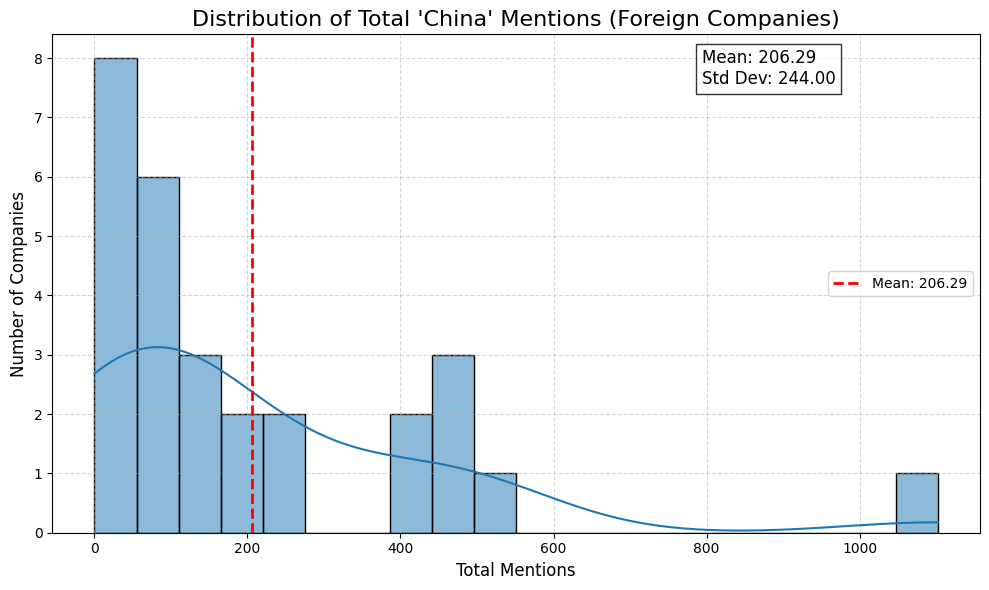

In [ ]:
# Plot Histogram of Total Mentions for Foreign Companies
plt.figure(figsize=(10, 6))
sns.histplot(pivot_foreign['Total_Mentions'], bins=20, kde=True)

# Calculate statistics
mean_val_foreign = pivot_foreign['Total_Mentions'].mean()
std_val_foreign = pivot_foreign['Total_Mentions'].std()

# Add vertical line for the mean
plt.axvline(mean_val_foreign, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val_foreign:.2f}')

# Add text annotation for Mean and Std Dev
plt.text(0.7, 0.9, f'Mean: {mean_val_foreign:.2f}\nStd Dev: {std_val_foreign:.2f}',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.title("Distribution of Total 'China' Mentions (Foreign Companies)", fontsize=16)
plt.xlabel("Total Mentions", fontsize=12)
plt.ylabel("Number of Companies", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import os

output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Saving filings to ./output/...")

for company, filings in filtered_foreign_filings_dict.items():
    if company not in d_companies_foreign:
        print(f"Skipping {company}: Metadata not found.")
        continue

    ticker = d_companies_foreign[company].get('ticker', company)
    # Sanitize ticker for filename just in case
    safe_ticker = "".join([c for c in ticker if c.isalnum() or c in ('-', '_')]).strip()

    company_dir = os.path.join(output_dir, safe_ticker)
    if not os.path.exists(company_dir):
        os.makedirs(company_dir)

    cik = d_companies_foreign[company]['cik']

    for filing in filings:
        form, date, acc, primary_doc = filing
        year = date[:4]

        # unique filename: year_form_accession.txt
        filename = f"{year}_{form}_{acc}.txt"
        filepath = os.path.join(company_dir, filename)

        if os.path.exists(filepath):
            continue # Already downloaded

        text = get_filing_text(cik, acc, primary_doc)

        if text:
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
            print(f"  Saved {safe_ticker}/{filename}")
        else:
            print(f"  Failed to download {safe_ticker}/{filename}")

        time.sleep(0.1)

print("Done saving filings.")

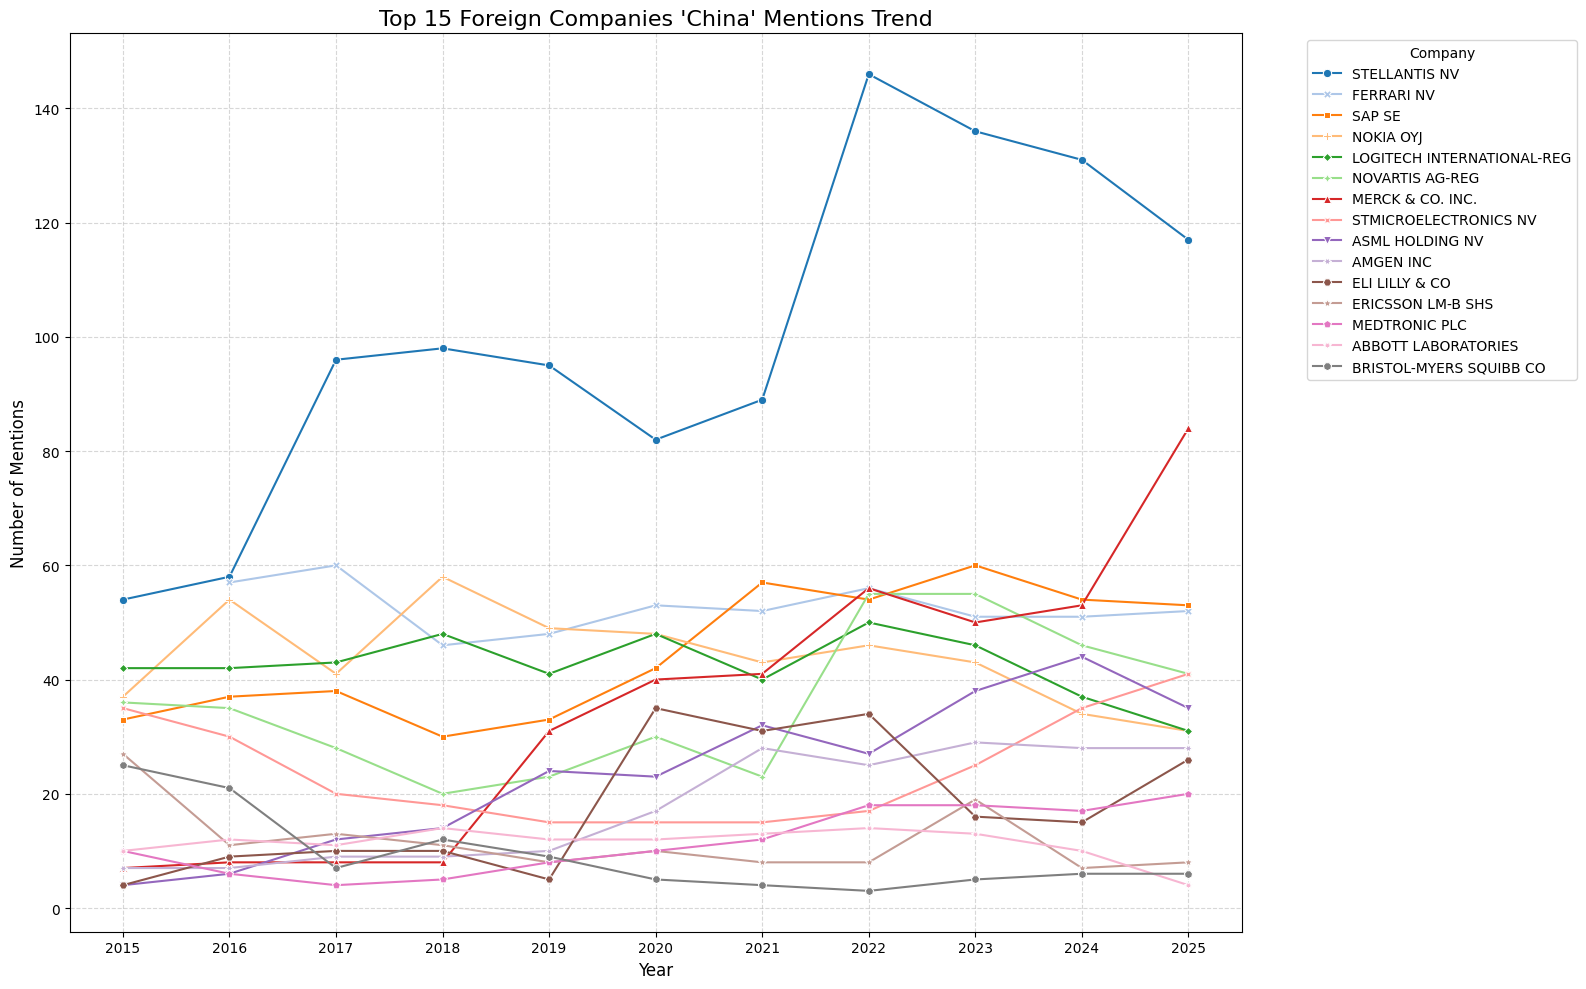

In [ ]:
# Prepare data for plotting
# Take top 15, drop the 'Total_Mentions' column to keep only years
top_15_foreign_trend = pivot_foreign_sorted.head(15).drop(columns=['Total_Mentions'])

# Transpose the DataFrame so Years are on the index (X-axis) and Companies are columns (Lines)
top_15_foreign_trend_T = top_15_foreign_trend.transpose()

# Plotting
plt.figure(figsize=(16, 10))

# Using seaborn to plot all columns in the transposed dataframe
sns.lineplot(data=top_15_foreign_trend_T, dashes=False, markers=True, palette="tab20")

plt.title("Top 15 Foreign Companies 'China' Mentions Trend", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Mentions", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Company', ncol=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

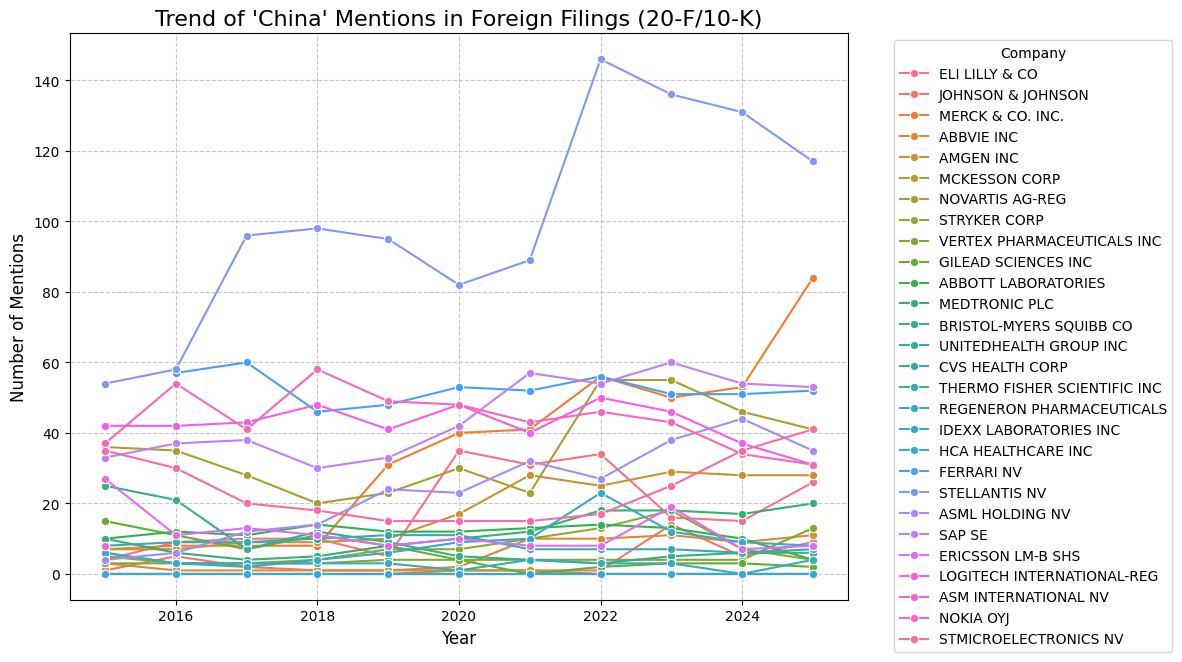

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_foreign_counts' in locals() and not df_foreign_counts.empty:
    plt.figure(figsize=(12, 7))

    # Ensure Year is numeric for plotting
    df_plot = df_foreign_counts.copy()
    df_plot['Year'] = pd.to_numeric(df_plot['Year'])

    # Plot
    sns.lineplot(data=df_plot, x='Year', y='China_Mentions', hue='Company', marker='o')

    plt.title("Trend of 'China' Mentions in Foreign Filings (20-F/10-K)", fontsize=16)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of Mentions", fontsize=12)
    plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")

In [ ]:
# 1. Identify Top 5 Companies from the previous analysis
top_5_tickers = top_30_companies_tickers.head(5).index.tolist()
# Map tickers back to Company Names if the dictionary keys are Names
# Our 'all_years_ten_k_dict' keys are Company Names (e.g. 'General Motors Co')
# 'top_30_companies_tickers' index is Ticker (e.g. 'GM') if we renamed it, OR it might still be Company Name depending on previous execution.
# Let's check the index of top_30_companies_tickers from the previous display.
# The previous display showed 'Company' as index with values like 'GM', 'MPWR'.
# Wait, the previous cell 'fc87ebef' renamed the index to tickers.
# We need to map Tickers back to Company Names to access 'all_years_ten_k_dict'.

# Invert the name_to_ticker map created earlier
ticker_to_name = {v: k for k, v in name_to_ticker.items()}

top_5_names = []
for t in top_5_tickers:
    if t in ticker_to_name:
        top_5_names.append(ticker_to_name[t])
    else:
        # Fallback if the index wasn't tickers or lookup fails
        top_5_names.append(t)

print(f"Top 5 Companies for Table Analysis: {top_5_names}")

# 2. Create a subset dictionary for these 5 companies
top_5_ten_k_dict = {name: all_years_ten_k_dict[name] for name in top_5_names if name in all_years_ten_k_dict}

# 3. Extract tables for this subset
print("\nStarting table extraction for Top 5 companies (this may take a moment)...")
top_5_extracted_tables = extract_tables_from_filings(top_5_ten_k_dict)

Top 5 Companies for Table Analysis: ['General Motors Co', 'MONOLITHIC POWER SYSTEMS INC', 'Aptiv PLC', 'QUALCOMM INC/DE', 'FORD MOTOR CO']

Starting table extraction for Top 5 companies (this may take a moment)...
Processing tables for General Motors Co...
  Fetching 10-K from 2025-01-28...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)
/usr/local/lib/python3.12/dist-packages/pandas/io/html.py:661: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=X

    Extracted 128 tables.
  Fetching 10-K from 2024-01-30...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)
/usr/local/lib/python3.12/dist-packages/pandas/io/html.py:661: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=X

    Extracted 126 tables.
  Fetching 10-K from 2023-01-31...


...

    Extracted 291 tables.
  Fetching 10-K from 2016-02-11...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)


    Extracted 375 tables.
  Fetching 10-K from 2015-02-13...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)


    Extracted 380 tables.


In [ ]:
# 4. Filter these extracted tables for Geographic Keywords
geo_tables_top_5 = {}

print("\nFiltering extracted tables for geographic keywords...")
for company, data_by_date in top_5_extracted_tables.items():
    geo_tables_top_5[company] = {}
    for date, tables in data_by_date.items():
        matching_tables = []
        for df in tables:
            if df.empty or df.shape[1] == 0:
                continue

            try:
                # Check leftmost column for keywords
                first_col_values = df.iloc[:, 0].astype(str)
                is_match = False
                for val in first_col_values:
                    for keyword in geo_keywords:
                        if keyword in val:
                            is_match = True
                            break
                    if is_match:
                        break

                if is_match:
                    matching_tables.append(df)
            except:
                continue

        if matching_tables:
            geo_tables_top_5[company][date] = matching_tables
            print(f"  {company} ({date}): Found {len(matching_tables)} geographic tables.")

# 5. Display a sample table
if geo_tables_top_5:
    first_co = next(iter(geo_tables_top_5))
    first_dt = next(iter(geo_tables_top_5[first_co]))
    print(f"\nSample Geographic Table from {first_co} ({first_dt}):")
    display(geo_tables_top_5[first_co][first_dt][0].head(10))
else:
    print("No geographic tables found for the Top 5.")


Filtering extracted tables for geographic keywords...
  General Motors Co (2025-01-28): Found 9 geographic tables.
  General Motors Co (2024-01-30): Found 8 geographic tables.
  General Motors Co (2023-01-31): Found 7 geographic tables.
  General Motors Co (2022-02-02): Found 7 geographic tables.
  General Motors Co (2021-02-10): Found 7 geographic tables.
  General Motors Co (2020-02-05): Found 7 geographic tables.
  General Motors Co (2019-02-06): Found 8 geographic tables.
  General Motors Co (2018-02-06): Found 8 geographic tables.
  General Motors Co (2017-02-07): Found 8 geographic tables.
  General Motors Co (2016-02-03): Found 5 geographic tables.
  General Motors Co (2015-02-04): Found 5 geographic tables.
  MONOLITHIC POWER SYSTEMS INC (2025-03-03): Found 2 geographic tables.
  MONOLITHIC POWER SYSTEMS INC (2024-02-29): Found 3 geographic tables.
  MONOLITHIC POWER SYSTEMS INC (2023-02-24): Found 4 geographic tables.
  MONOLITHIC POWER SYSTEMS INC (2022-02-25): Found 4 geogr

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,"Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,",...,"Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,","Years Ended December 31,"
2,NaN,NaN,NaN,2024,2024,2024,2024,2024,2024,2024,...,2022,2022,2022,2022,2022,2022,2022,2022,2022,2022
3,NaN,NaN,NaN,Industry,Industry,Industry,NaN,NaN,NaN,GM,...,NaN,GM,GM,GM,NaN,NaN,NaN,Market Share,Market Share,Market Share
4,North America,North America,North America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,United States,United States,United States,16385,16385,NaN,NaN,NaN,NaN,2705,...,NaN,2274,2274,NaN,NaN,NaN,NaN,16.0,16.0,%
6,Other,Other,Other,3909,3909,NaN,NaN,NaN,NaN,510,...,NaN,406,406,NaN,NaN,NaN,NaN,13.2,13.2,%
7,Total North America,Total North America,Total North America,20294,20294,NaN,NaN,NaN,NaN,3215,...,NaN,2680,2680,NaN,NaN,NaN,NaN,15.5,15.5,%
8,"Asia/Pacific, Middle East and Africa","Asia/Pacific, Middle East and Africa","Asia/Pacific, Middle East and Africa",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,China(a),China(a),China(a),26567,26567,NaN,NaN,NaN,NaN,1839,...,NaN,2303,2303,NaN,NaN,NaN,NaN,9.8,9.8,%


In [ ]:
# Calculate Total Mentions per Company
pivot_table_all['Total_Mentions'] = pivot_table_all.sum(axis=1)

# Sort by Total Mentions descending
pivot_table_all_sorted_tickers = pivot_table_all.sort_values(by='Total_Mentions', ascending=False)

# Get Top 30 Companies
top_30_companies_tickers = pivot_table_all_sorted_tickers.head(30)

print("Top 30 Companies by Total 'China' Mentions (Tickers):")
display(top_30_companies_tickers[['Total_Mentions']])

Top 30 Companies by Total 'China' Mentions (Tickers):


Year,Total_Mentions
Company,
GM,1796
MPWR,1528
APTV,1178
QCOM,1030
F,972
VTRS,930
MTD,824
TSLA,788
ISRG,782


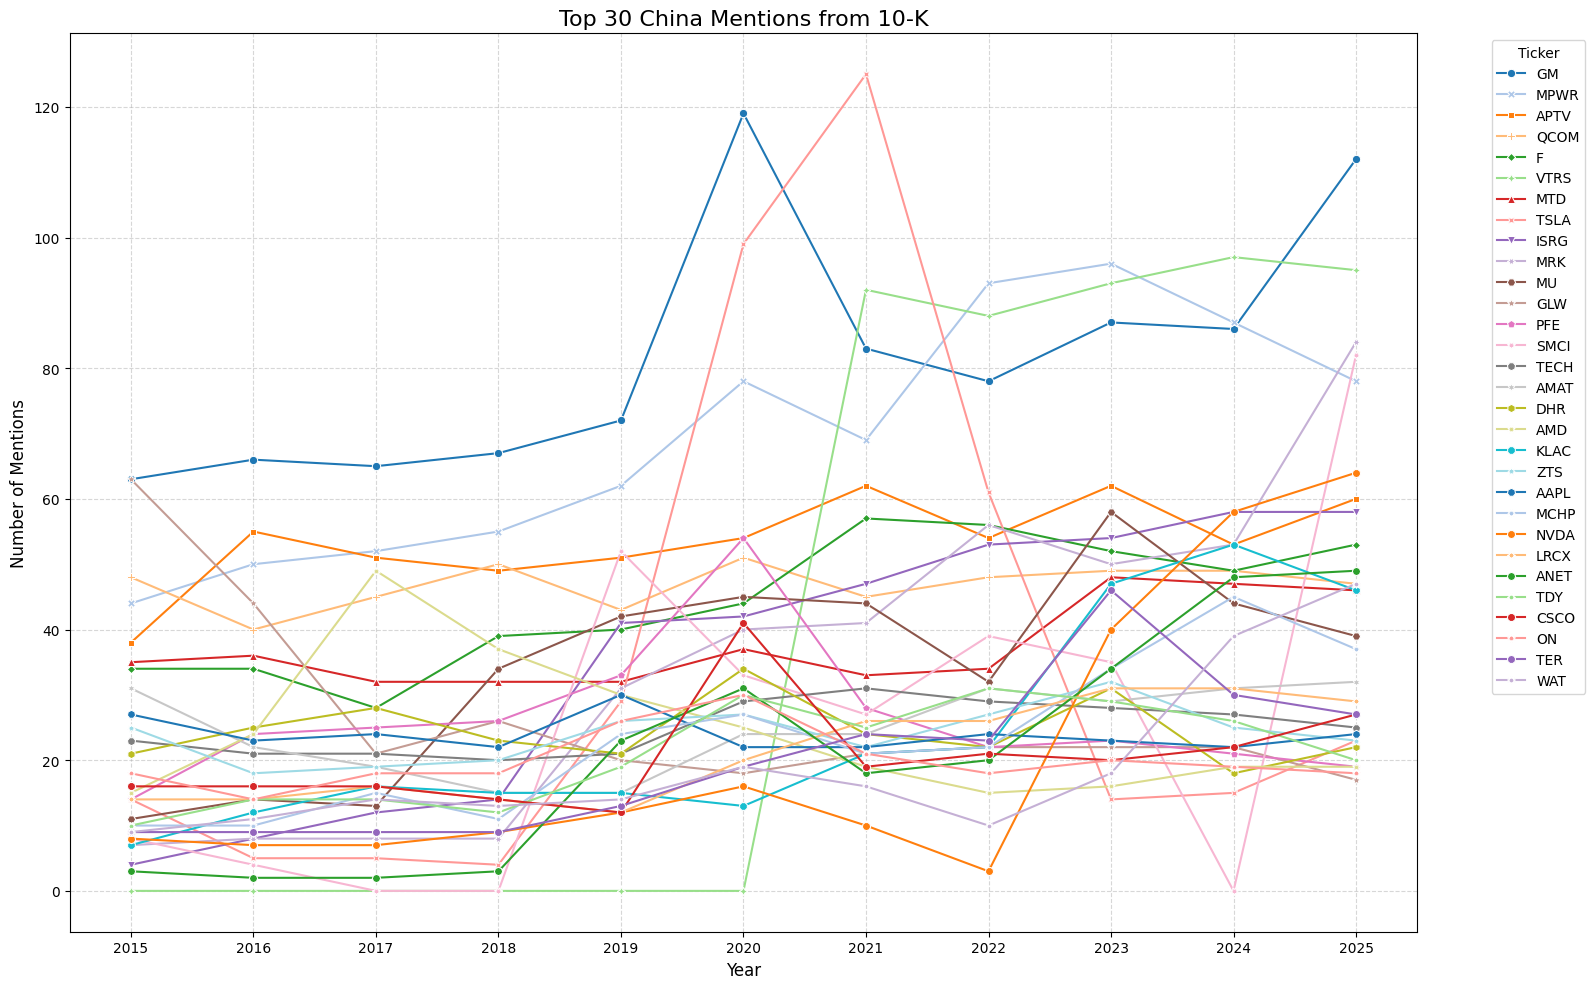

In [ ]:
# Prepare data for plotting
# Take top 30, drop the 'Total_Mentions' column to keep only years
top_30_trend_data = pivot_table_all_sorted_tickers.head(30).drop(columns=['Total_Mentions'])

# Transpose the DataFrame so Years are on the index (X-axis) and Companies are columns (Lines)
top_30_trend_data_T = top_30_trend_data.transpose()

# Plotting
plt.figure(figsize=(16, 10))

# Using seaborn to plot all columns in the transposed dataframe
sns.lineplot(data=top_30_trend_data_T, dashes=False, markers=True, palette="tab20")

plt.title("Top 30 China Mentions from 10-K", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Mentions", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Ticker', ncol=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
filtered_foreign_filings_dict = {}
target_years = [str(y) for y in range(2015, 2026)]

for company, filings in foreign_filings_dict.items():
    filtered_filings = []
    for filing in filings:
        form, date, acc, primary_doc = filing
        # Check if form is 10-K or 20-F and year is in target
        if form in ['10-K', '20-F'] and date[:4] in target_years:
            filtered_filings.append(filing)

    if filtered_filings:
        filtered_foreign_filings_dict[company] = filtered_filings

print(f"Filtered foreign dictionary created with {len(filtered_foreign_filings_dict)} companies.")
for k, v in filtered_foreign_filings_dict.items():
    print(f"{k}: {v}")

Filtered foreign dictionary created with 5 companies.
argenx SE: [('20-F', '2025-03-20', '0001697862-25-000024', 'argx-20241231.htm'), ('20-F', '2020-03-31', '0001558370-20-003438', 'argx-20191231x20f.htm')]
ASML Holding N.V.: [('20-F', '2025-03-05', '0000937966-25-000009', 'asml-20241231.htm'), ('20-F', '2020-02-12', '0000937966-20-000011', 'a2019integratedreportb.htm'), ('20-F', '2015-02-11', '0001193125-15-042676', 'd737660d20f.htm')]
EssilorLuxottica: [('10-K', '2025-08-20', '0001001250-25-000099', 'el-20250630.htm'), ('10-K', '2020-08-28', '0001001250-20-000065', 'el-20200630.htm'), ('10-K', '2015-08-20', '0001104659-15-061122', 'a15-12311_110k.htm')]
Sanofi: [('20-F', '2025-02-28', '0000891478-25-000054', 'san-20241231.htm'), ('20-F', '2020-03-06', '0000891478-20-000017', 'a20-f2019.htm'), ('20-F', '2015-04-29', '0001193125-15-156183', 'd914897d20f.htm')]
SAP SE: [('20-F', '2025-02-27', '0001104659-25-017815', 'sap-20241224x20f.htm'), ('20-F', '2020-02-27', '0001104659-20-025681'

In [ ]:
foreign_china_counts_data = []

print("Counting mentions of 'China' in foreign filings...")

for company, filings in filtered_foreign_filings_dict.items():
    if company not in d_companies_foreign or 'cik' not in d_companies_foreign[company]:
        continue
    cik = d_companies_foreign[company]['cik']

    for form, date, acc, primary_doc in filings:
        year = date[:4]
        text = get_filing_text(cik, acc, primary_doc)

        if text:
            count = text.lower().count("china")
            foreign_china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": count
            })
            print(f"  {company} ({year}): {count} mentions.")
        else:
            print(f"  {company} ({year}): Failed to download text.")
            foreign_china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": None
            })

        time.sleep(0.1)

# Display results
df_foreign_counts = pd.DataFrame(foreign_china_counts_data)
if not df_foreign_counts.empty:
    pivot_foreign = df_foreign_counts.pivot_table(
        index='Company',
        columns='Year',
        values='China_Mentions',
        aggfunc='sum'
    )
    print("\nPivot Table of 'China' Mentions (Foreign):")
    display(pivot_foreign)
else:
    print("No data collected.")

Counting mentions of 'China' in foreign filings...
  argenx SE (2025): 58 mentions.
  argenx SE (2020): 2 mentions.
  ASML Holding N.V. (2025): 35 mentions.
  ASML Holding N.V. (2020): 23 mentions.
  ASML Holding N.V. (2015): 4 mentions.
  EssilorLuxottica (2025): 26 mentions.
  EssilorLuxottica (2020): 19 mentions.
  EssilorLuxottica (2015): 14 mentions.
  Sanofi (2025): 18 mentions.
  Sanofi (2020): 18 mentions.
  Sanofi (2015): 10 mentions.
  SAP SE (2025): 53 mentions.
  SAP SE (2020): 42 mentions.
  SAP SE (2015): 33 mentions.

Pivot Table of 'China' Mentions (Foreign):


Year,2015,2020,2025
Company,,,
ASML Holding N.V.,4.0,23.0,35.0
EssilorLuxottica,14.0,19.0,26.0
SAP SE,33.0,42.0,53.0
Sanofi,10.0,18.0,18.0
argenx SE,NaN,2.0,58.0


In [ ]:
# Fetch CIKs for foreign companies
# Note: SEC tickers in company_tickers.json are usually US-listed.
# Foreign companies often list as ADRs (e.g., SAP, ASML) or have specific CIKs.
# We will try to match based on Ticker (stripped of extension) or Title if possible.

print("Updating CIKs for foreign companies...")

# Re-fetch SEC data to be sure we have the lookup
sec_url = "https://www.sec.gov/files/company_tickers.json"
try:
    response = requests.get(sec_url, headers=headers)
    sec_data = response.json()

    # Create lookups
    # 1. Ticker -> CIK (e.g. "ASML" -> CIK)
    # 2. Title -> CIK
    sec_ticker_lookup = {}
    sec_title_lookup = {}

    for entry in sec_data.values():
        sec_ticker_lookup[entry['ticker']] = str(entry['cik_str']).zfill(10)
        sec_title_lookup[entry['title'].lower()] = str(entry['cik_str']).zfill(10)

    for company, info in d_companies_foreign.items():
        ticker_full = info['ticker']
        # Remove extension for matching (e.g. "ASML.AS" -> "ASML")
        ticker_root = ticker_full.split('.')[0]

        found_cik = None

        # Try matching by root ticker
        if ticker_root in sec_ticker_lookup:
            found_cik = sec_ticker_lookup[ticker_root]

        # If not found, try matching by company name (fuzzy/exact)
        if not found_cik:
             # Try exact lower match
            if company.lower() in sec_title_lookup:
                found_cik = sec_title_lookup[company.lower()]

        if found_cik:
            d_companies_foreign[company]['cik'] = found_cik
            print(f"  Found CIK for {company} ({ticker_full}): {found_cik}")
        else:
            print(f"  Warning: Could not automatically find CIK for {company} ({ticker_full}).")
            # Manually adding some common ones if missed might be necessary later

except Exception as e:
    print(f"Error processing SEC data: {e}")

# Display updated dictionary
# for k, v in d_companies_foreign.items():
#     print(f"{k}: {v}")

Updating CIKs for foreign companies...
  Found CIK for argenx SE (ARGX.BR): 0001697862
  Found CIK for ASML Holding N.V. (ASML.AS): 0000937966
  Found CIK for EssilorLuxottica (EL.PA): 0001001250
  Found CIK for Infineon Technologies AG (IFX.DE): 0001107457
  Found CIK for Sanofi (SAN.PA): 0000891478
  Found CIK for SAP SE (SAP.DE): 0001000184


In [ ]:
foreign_filings_dict = {}

print("\nFetching filings for foreign companies...")
for e in d_companies_foreign:
    # Check if 'cik' key exists
    if "cik" not in d_companies_foreign[e]:
        print(f"Skipping '{e}' (No CIK found).")
        continue

    cik = d_companies_foreign[e]["cik"]
    print(f"Processing {e}...")

    # Foreign companies usually file 20-F instead of 10-K
    filings = get_filings(cik, forms=['10-K', '20-F'])

    if filings:
        print(f"  Found {len(filings)} filings.")
        foreign_filings_dict[e] = filings
    else:
        print(f"  No 10-K or 20-F filings found.")

# Preview
for e in foreign_filings_dict:
    print(f"\nExample ({e}): {foreign_filings_dict[e][:2]}")
    break


Fetching filings for foreign companies...
Processing argenx SE...
  Found 8 filings.
Processing ASML Holding N.V....
  Found 25 filings.
Skipping 'Bayer AG' (No CIK found).
Skipping 'Bayerische Motoren Werke AG' (No CIK found).
Processing EssilorLuxottica...
  Found 28 filings.
Processing Infineon Technologies AG...
  Found 9 filings.
Skipping 'Mercedes-Benz Group AG' (No CIK found).
Processing Sanofi...
  Found 25 filings.
Processing SAP SE...
  Found 28 filings.
Skipping 'Volkswagen AG' (No CIK found).

Example (argenx SE): [('20-F', '2025-03-20', '0001697862-25-000024', 'argx-20241231.htm'), ('20-F', '2024-03-21', '0001558370-24-003665', 'argx-20231231x20f.htm')]


In [ ]:
def get_cik(ticker):
    url = "https://www.sec.gov/files/company_tickers.json"

    try:
        data = requests.get(url, headers=headers).json()

        cik = next(
            str(v["cik_str"]).zfill(10)
            for v in data.values()
            if v["ticker"] == ticker
        )
        return cik
    except:
        print(f"{ticker}not found.")
        return

In [ ]:
d_companies = {
    "Tesla": {
        "ticker": "TSLA",
        "exchange": "NASDAQ",
        "country": "US",
    }
}

In [ ]:
# List of tickers provided
tickers_to_add = """
ACN ADBE AMD AKAM APH ADI AAPL AMAT APP ANET ADSK AVGO CDNS CDW CIEN CSCO CTSH GLW CRWD DDOG DELL EPAM FFIV FICO FSLR FTNT IT GEN GDDY HPE HPQ IBM INTC INTU JBL KEYS KLAC LRCX MCHP MU MSFT MPWR MSI NTAP NVDA NXPI ON ORCL PLTR PANW PTC QCOM Q ROP CRM SNDK STX NOW SWKS SMCI SNPS TEL TDY TER TXN TRMB TYL VRSN WDC WDAY ZBRA ABT ABBV A ALGN AMGN BAX BDX TECH BIIB BSX BMY CAH COR CNC CRL CI COO CVS DHR DVA DXCM EW ELV GEHC GILD HCA HSIC HOLX HUM IDXX INCY PODD ISRG IQV JNJ LH LLY MCK MDT MRK MTD MRNA MOH PFE DGX REGN RMD RVTY SOLV STE SYK TMO UNH UHS VRTX VTRS WAT WST ZBH ZTS APTV AZO CVNA F GM ORLY TSLA
""".split()

# Fetch current SEC ticker mapping to get Company Names and CIKs
print("Fetching SEC company data...")
sec_url = "https://www.sec.gov/files/company_tickers.json"
try:
    response = requests.get(sec_url, headers=headers)
    sec_data = response.json()

    # Create a lookup: Ticker -> {Title, CIK}
    sec_lookup = {}
    for entry in sec_data.values():
        sec_lookup[entry['ticker']] = {
            "title": entry['title'],
            "cik": str(entry['cik_str']).zfill(10)
        }

    # Update d_companies
    count_added = 0
    for ticker in tickers_to_add:
        if ticker in sec_lookup:
            info = sec_lookup[ticker]
            title = info['title']

            # Clean title slightly (optional, e.g., remove "Inc.") or keep official
            # Using official title as key
            d_companies[title] = {
                "ticker": ticker,
                "exchange": "US", # General placeholder as requested
                "country": "US",
                "cik": info['cik']
            }
            count_added += 1
        else:
            print(f"Warning: Ticker {ticker} not found in current SEC data (possibly delisted or acquired).")
            # Add with fallback
            d_companies[ticker] = {
                "ticker": ticker,
                "exchange": "US",
                "country": "US"
            }

    print(f"\nSuccessfully added/updated {count_added} companies to d_companies.")
    print(f"Total entries in d_companies: {len(d_companies)}")

except Exception as e:
    print(f"Error fetching or processing SEC data: {e}")

Fetching SEC company data...

Successfully added/updated 138 companies to d_companies.
Total entries in d_companies: 139


In [ ]:
# Preview the first 5 entries of d_companies to verify format
for i, (k, v) in enumerate(d_companies.items()):
    print(f"{k}: {v}")

Tesla: {'ticker': 'TSLA', 'exchange': 'NASDAQ', 'country': 'US'}
Accenture plc: {'ticker': 'ACN', 'exchange': 'US', 'country': 'US', 'cik': '0001467373'}
ADOBE INC.: {'ticker': 'ADBE', 'exchange': 'US', 'country': 'US', 'cik': '0000796343'}
ADVANCED MICRO DEVICES INC: {'ticker': 'AMD', 'exchange': 'US', 'country': 'US', 'cik': '0000002488'}
AKAMAI TECHNOLOGIES INC: {'ticker': 'AKAM', 'exchange': 'US', 'country': 'US', 'cik': '0001086222'}
AMPHENOL CORP /DE/: {'ticker': 'APH', 'exchange': 'US', 'country': 'US', 'cik': '0000820313'}
ANALOG DEVICES INC: {'ticker': 'ADI', 'exchange': 'US', 'country': 'US', 'cik': '0000006281'}
Apple Inc.: {'ticker': 'AAPL', 'exchange': 'US', 'country': 'US', 'cik': '0000320193'}
APPLIED MATERIALS INC /DE: {'ticker': 'AMAT', 'exchange': 'US', 'country': 'US', 'cik': '0000006951'}
AppLovin Corp: {'ticker': 'APP', 'exchange': 'US', 'country': 'US', 'cik': '0001751008'}
Arista Networks, Inc.: {'ticker': 'ANET', 'exchange': 'US', 'country': 'US', 'cik': '000159

In [ ]:
ten_k_dict = {}
for e in d_companies:
    # Check if 'cik' key exists before accessing it
    if "cik" not in d_companies[e]:
        print(f"Skipping '{e}' (No CIK found). This may be a duplicate or manual entry.")
        continue

    cik = d_companies[e]["cik"]
    print(f"Processing {e} ({d_companies[e]['ticker']})...")
    # Fetch 10-K, 10-Q, and 20-F
    filings = get_filings(cik, forms=['10-K', '10-Q', '20-F'])
    print(f"Found {len(filings)} filings.")
    ten_k_dict[e] = filings


# Show the first entry of the first company with data to verify
for e in ten_k_dict:
    if ten_k_dict[e]:
        print(f"\nExample ({e}): {ten_k_dict[e][:1]}")
        break

Skipping 'Tesla' (No CIK found). This may be a duplicate or manual entry.
Processing Accenture plc (ACN)...
Found 66 filings.
Processing ADOBE INC. (ADBE)...
Found 125 filings.
Processing ADVANCED MICRO DEVICES INC (AMD)...
Found 125 filings.
Processing AKAMAI TECHNOLOGIES INC (AKAM)...
Found 103 filings.
Processing AMPHENOL CORP /DE/ (APH)...
Found 118 filings.
Processing ANALOG DEVICES INC (ADI)...
Found 128 filings.
Processing Apple Inc. (AAPL)...
Found 126 filings.
Processing APPLIED MATERIALS INC /DE (AMAT)...
Found 126 filings.
Processing AppLovin Corp (APP)...
Found 20 filings.
Processing Arista Networks, Inc. (ANET)...
Found 47 filings.
Processing Autodesk, Inc. (ADSK)...
Found 125 filings.
Processing Broadcom Inc. (AVGO)...
Found 31 filings.
Processing CADENCE DESIGN SYSTEMS INC (CDNS)...
Found 127 filings.
Processing CDW Corp (CDW)...
Found 62 filings.
Processing CIENA CORP (CIEN)...
Found 117 filings.
Processing CISCO SYSTEMS, INC. (CSCO)...
Found 124 filings.
Processing COG

In [ ]:
ten_k_dict

{'Accenture plc': [('10-Q',
   '2025-12-18',
   '0001467373-25-000222',
   'acn-20251130.htm'),
  ('10-K', '2025-10-10', '0001467373-25-000217', 'acn-20250831.htm'),
  ('10-Q', '2025-06-20', '0001467373-25-000169', 'acn-20250531.htm'),
  ('10-Q', '2025-03-20', '0001467373-25-000100', 'acn-20250228.htm'),
  ('10-Q', '2024-12-19', '0001467373-24-000352', 'acn-20241130.htm'),
  ('10-K', '2024-10-10', '0001467373-24-000278', 'acn-20240831.htm'),
  ('10-Q', '2024-06-20', '0001467373-24-000196', 'acn-20240531.htm'),
  ('10-Q', '2024-03-21', '0001467373-24-000108', 'acn-20240229.htm'),
  ('10-Q', '2023-12-19', '0001467373-23-000403', 'acn-20231130.htm'),
  ('10-K', '2023-10-12', '0001467373-23-000324', 'acn-20230831.htm'),
  ('10-Q', '2023-06-22', '0001467373-23-000221', 'acn-20230531.htm'),
  ('10-Q', '2023-03-23', '0001467373-23-000124', 'acn-20230228.htm'),
  ('10-Q', '2022-12-16', '0001467373-22-000370', 'acn-20221130.htm'),
  ('10-K', '2022-10-12', '0001467373-22-000295', 'acn-20220831.h

In [ ]:
filtered_ten_k_dict = {}
target_years = [str(y) for y in range(2015, 2026)]

for company, filings in ten_k_dict.items():
    filtered_filings = []
    for filing in filings:
        form, date, acc, primary_doc = filing
        # Check if form is 10-K and the year part of the date (YYYY-MM-DD) is in target_years
        if form == '10-K' and date[:4] in target_years:
            filtered_filings.append(filing)

    # Only add the company if they have matching filings
    if filtered_filings:
        filtered_ten_k_dict[company] = filtered_filings

print(f"Filtered dictionary created with {len(filtered_ten_k_dict)} companies having matching 10-Ks.")

# Preview a few entries to verify
for i, (k, v) in enumerate(filtered_ten_k_dict.items()):
    if i >= 3: break
    print(f"{k}: {v}")

Filtered dictionary created with 137 companies having matching 10-Ks.
Accenture plc: [('10-K', '2025-10-10', '0001467373-25-000217', 'acn-20250831.htm'), ('10-K', '2020-10-22', '0001467373-20-000376', 'acn-20200831.htm'), ('10-K', '2015-10-30', '0001467373-15-000457', 'acn831201510k.htm')]
ADOBE INC.: [('10-K', '2025-01-13', '0000796343-25-000004', 'adbe-20241129.htm'), ('10-K', '2020-01-21', '0000796343-20-000013', 'adbe10kfy19.htm'), ('10-K', '2015-01-20', '0000796343-15-000022', 'adbe10kfy14.htm')]
ADVANCED MICRO DEVICES INC: [('10-K', '2025-02-05', '0000002488-25-000012', 'amd-20241228.htm'), ('10-K', '2020-02-04', '0000002488-20-000008', 'amdform10-kfy2019.htm'), ('10-K', '2015-02-19', '0001193125-15-054362', 'd871455d10k.htm')]


In [ ]:
def extract_tables_from_filings(filings_dict):
    """
    Iterates through the filings dictionary, downloads the HTML content,
    and extracts all tables using pd.read_html.

    Returns a dictionary structure:
    {
        "Company Name": {
            "YYYY-MM-DD": [DataFrame_1, DataFrame_2, ...]
        }
    }
    """
    all_tables = {}

    for company, filings in filings_dict.items():
        all_tables[company] = {}
        print(f"Processing tables for {company}...")

        # Get CIK for fetching text
        # We need to look back at d_companies to get the CIK based on the company name key
        if company not in d_companies or 'cik' not in d_companies[company]:
            print(f"Warning: CIK not found for {company}, skipping.")
            continue

        cik = d_companies[company]['cik']

        for form, date, acc, primary_doc in filings:
            print(f"  Fetching {form} from {date}...")
            html_text = get_filing_text(cik, acc, primary_doc)

            if html_text:
                try:
                    # extracting tables
                    # flavor='bs4' is often more robust for soup-based parsing if lxml fails
                    # regex matching might be needed for very large files to find table tags if memory is an issue,
                    # but pd.read_html is the requested method.
                    dfs = pd.read_html(html_text)
                    all_tables[company][date] = dfs
                    print(f"    Extracted {len(dfs)} tables.")
                except ValueError as ve:
                    print(f"    No tables found or error parsing: {ve}")
                except Exception as e:
                    print(f"    Error: {e}")
            else:
                print("    Failed to download text.")

            # Polite delay
            time.sleep(0.2)

    return all_tables

In [ ]:
# Example usage: Extract tables for the first 2 companies to test (to save time)
# You can remove the slicing [:2] to process the whole dictionary.

subset_dict = dict(list(filtered_ten_k_dict.items())[:2])
extracted_tables_data = extract_tables_from_filings(subset_dict)

# Check the first result
first_company = next(iter(extracted_tables_data))
first_date = next(iter(extracted_tables_data[first_company]))
print(f"\nTables for {first_company} on {first_date}: {len(extracted_tables_data[first_company][first_date])} found.")

# Display the first table of the first entry if it exists
if extracted_tables_data[first_company][first_date]:
    display(extracted_tables_data[first_company][first_date][0].head())

Processing tables for Accenture plc...
  Fetching 10-K from 2025-10-10...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)
/usr/local/lib/python3.12/dist-packages/pandas/io/html.py:661: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=X

    Extracted 188 tables.
  Fetching 10-K from 2020-10-22...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)


    Extracted 176 tables.
  Fetching 10-K from 2015-10-30...


...

/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)
/usr/local/lib/python3.12/dist-packages/pandas/io/html.py:661: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=X

    Extracted 214 tables.
  Fetching 10-K from 2015-01-20...


/tmp/ipykernel_271/2289048492.py:37: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(html_text)


    Extracted 229 tables.

Tables for Accenture plc on 2025-10-10: 188 found.


,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,☑,☑,☑,Annual Report Pursuant to Section 13 or 15(d) ...,Annual Report Pursuant to Section 13 or 15(d) ...,Annual Report Pursuant to Section 13 or 15(d) ...


In [ ]:
geo_keywords = [
    'United States', 'China', 'Europe', 'Asia Pacific', 'Japan',
    'Germany', 'International', 'North America', 'EMEA', 'Americas'
]
print("Geographic keywords defined:", geo_keywords)

Geographic keywords defined: ['United States', 'China', 'Europe', 'Asia Pacific', 'Japan', 'Germany', 'International', 'North America', 'EMEA', 'Americas']


In [ ]:
geo_breakdown_tables = {}

print("Filtering tables for geographic keywords...")

for company, data_by_date in extracted_tables_data.items():
    geo_breakdown_tables[company] = {}
    for date, tables in data_by_date.items():
        matching_tables = []
        for df in tables:
            # Convert dataframe to string to search for keywords
            # Using .to_string() captures headers and values
            df_str = df.to_string()

            # Check if any keyword is in the dataframe string
            if any(keyword in df_str for keyword in geo_keywords):
                matching_tables.append(df)

        if matching_tables:
            geo_breakdown_tables[company][date] = matching_tables
            print(f"  {company} ({date}): Found {len(matching_tables)} geographic tables.")

# Verification: Display the first matching table found
first_match_company = next(iter(geo_breakdown_tables), None)
if first_match_company:
    first_match_date = next(iter(geo_breakdown_tables[first_match_company]), None)
    if first_match_date:
        print(f"\nSample table from {first_match_company} on {first_match_date}:")
        display(geo_breakdown_tables[first_match_company][first_match_date][0].head())
else:
    print("No geographic tables found.")

Filtering tables for geographic keywords...
  Accenture plc (2025-10-10): Found 13 geographic tables.
  Accenture plc (2020-10-22): Found 9 geographic tables.
  Accenture plc (2015-10-30): Found 27 geographic tables.
  ADOBE INC. (2025-01-13): Found 6 geographic tables.
  ADOBE INC. (2020-01-21): Found 8 geographic tables.
  ADOBE INC. (2015-01-20): Found 10 geographic tables.

Sample table from Accenture plc on 2025-10-10:


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,Fiscal 2025 Highlights,Fiscal 2025 Highlights,Fiscal 2025 Highlights
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,We serve clients and manage our business throu...,We serve clients and manage our business throu...,We serve clients and manage our business throu...,NaN,NaN,NaN,$69.7B in revenuesOur revenues are derived pri...,$69.7B in revenuesOur revenues are derived pri...,$69.7B in revenuesOur revenues are derived pri...


In [ ]:
geo_breakdown_tables = {}

print("Refining filter: Checking for geographic keywords in the leftmost column only...")

for company, data_by_date in extracted_tables_data.items():
    geo_breakdown_tables[company] = {}
    for date, tables in data_by_date.items():
        matching_tables = []
        for df in tables:
            # Skip empty DataFrames or those with no columns
            if df.empty or df.shape[1] == 0:
                continue

            try:
                # Access the first column.
                # We use .iloc[:, 0] to get the first column regardless of its name.
                # Convert to string to handle numeric types mixed with text.
                first_col_values = df.iloc[:, 0].astype(str)

                # Check if any keyword is present in any cell of the first column
                # We use a generator expression for efficiency
                is_match = False
                for val in first_col_values:
                    for keyword in geo_keywords:
                        if keyword in val:
                            is_match = True
                            break
                    if is_match:
                        break

                if is_match:
                    matching_tables.append(df)
            except Exception as e:
                # In case of index errors or other issues, skip the table
                continue

        if matching_tables:
            geo_breakdown_tables[company][date] = matching_tables
            print(f"  {company} ({date}): Found {len(matching_tables)} geographic tables (leftmost column match).")

# Verification: Display the first matching table found with the new logic
first_match_company = next(iter(b), None)
if first_match_company:
    first_match_date = next(iter(geo_breakdown_tables[first_match_company]), None)
    if first_match_date:
        print(f"\nSample refined table from {first_match_company} on {first_match_date}:")
        display(geo_breakdown_tables[first_match_company][first_match_date][0].head())
else:
    print("No geographic tables found with the refined criteria.")

Refining filter: Checking for geographic keywords in the leftmost column only...
  Accenture plc (2025-10-10): Found 7 geographic tables (leftmost column match).
  Accenture plc (2020-10-22): Found 5 geographic tables (leftmost column match).
  Accenture plc (2015-10-30): Found 3 geographic tables (leftmost column match).
  ADOBE INC. (2025-01-13): Found 5 geographic tables (leftmost column match).
  ADOBE INC. (2020-01-21): Found 7 geographic tables (leftmost column match).
  ADOBE INC. (2015-01-20): Found 7 geographic tables (leftmost column match).

Sample refined table from Accenture plc on 2025-10-10:


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,Fiscal 2025 Highlights,Fiscal 2025 Highlights,Fiscal 2025 Highlights
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,We serve clients and manage our business throu...,We serve clients and manage our business throu...,We serve clients and manage our business throu...,NaN,NaN,NaN,$69.7B in revenuesOur revenues are derived pri...,$69.7B in revenuesOur revenues are derived pri...,$69.7B in revenuesOur revenues are derived pri...


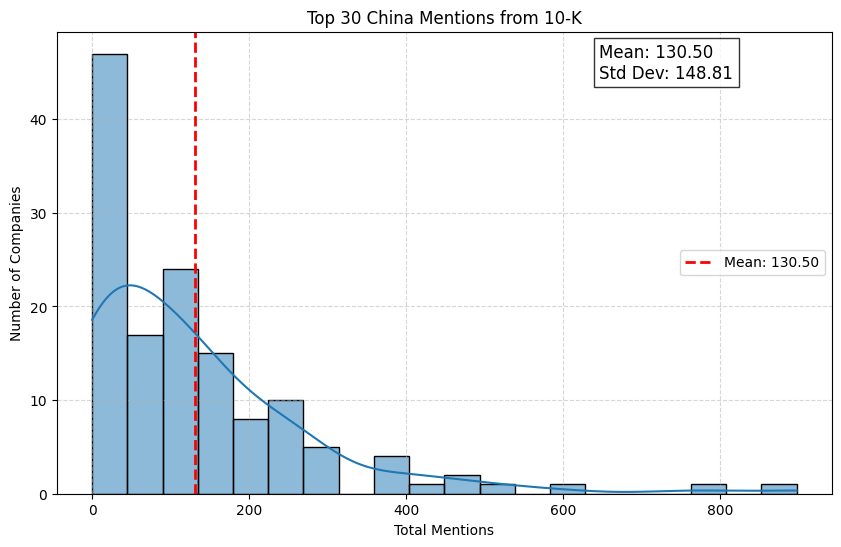

Top 30 China Mentions:


Year,Total_Mentions
Company,
GM,898
MPWR,764
APTV,589
QCOM,515
F,486
VTRS,465
MTD,412
TSLA,394
ISRG,391


In [ ]:
# Plot Histogram of Total Mentions
plt.figure(figsize=(10, 6))
sns.histplot(pivot_table_all['Total_Mentions'], bins=20, kde=True)

# Calculate statistics
mean_val = pivot_table_all['Total_Mentions'].mean()
std_val = pivot_table_all['Total_Mentions'].std()

# Add vertical line for the mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

# Add text annotation for Mean and Std Dev
plt.text(0.7, 0.9, f'Mean: {mean_val:.2f}\nStd Dev: {std_val:.2f}',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.title("Top 30 China Mentions from 10-K")
plt.xlabel("Total Mentions")
plt.ylabel("Number of Companies")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Get Top 30 Companies
top_30_companies = pivot_table_all.sort_values(by='Total_Mentions', ascending=False).head(30)
print("Top 30 China Mentions:")
display(top_30_companies[['Total_Mentions']])

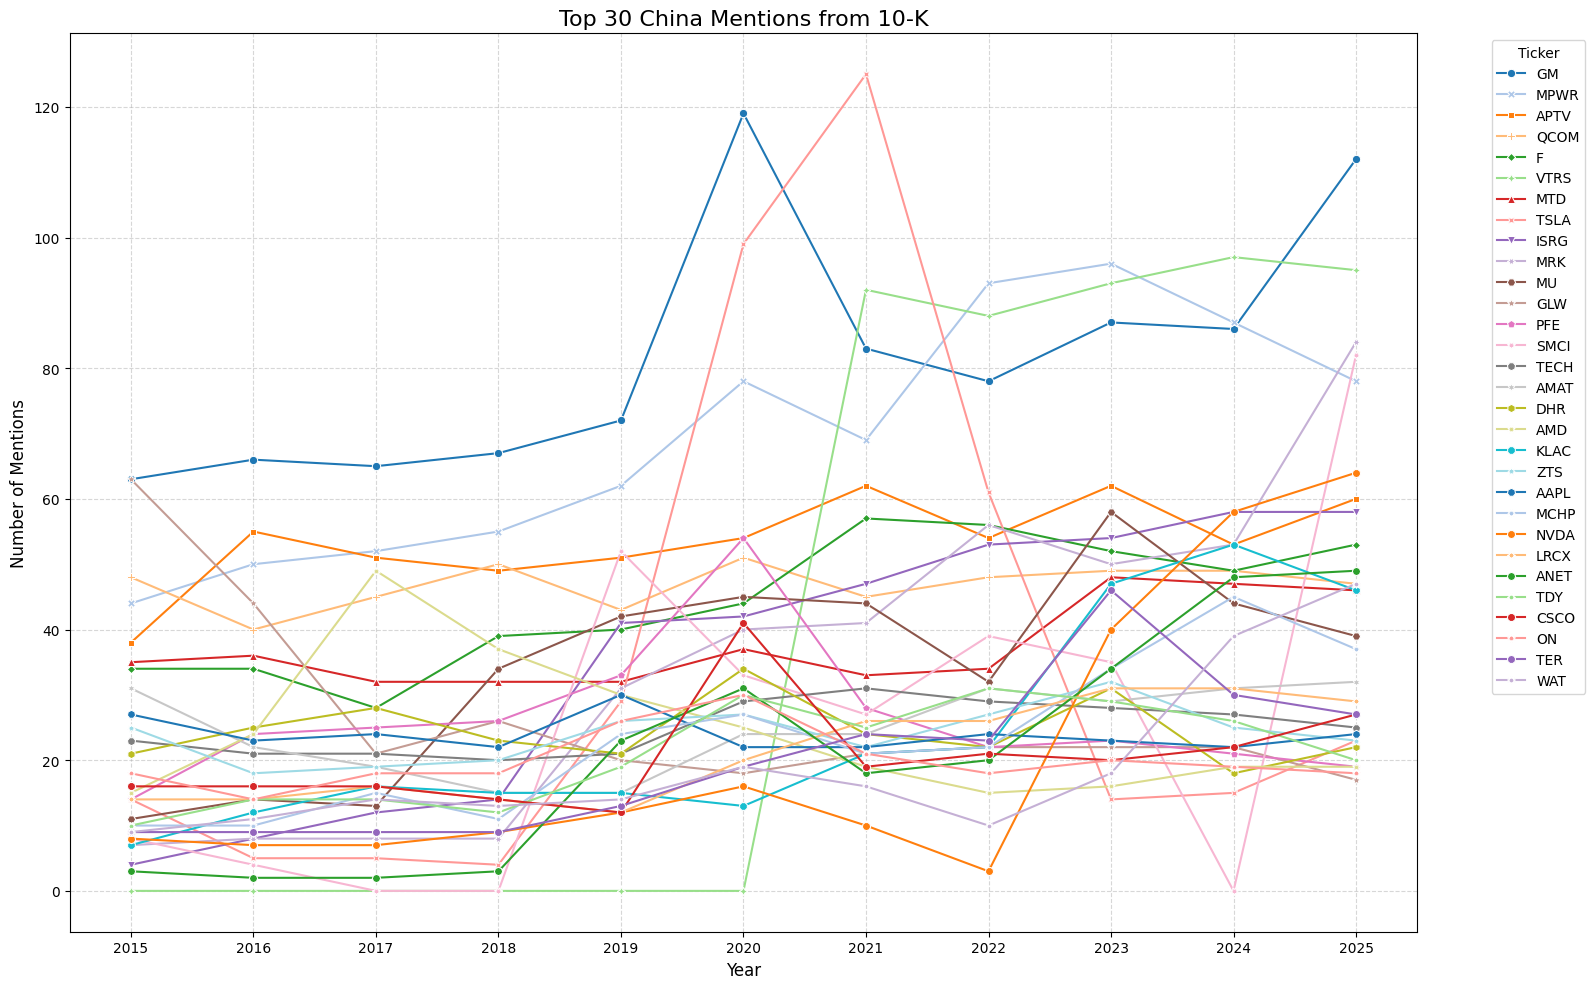

In [ ]:
# Prepare data for plotting
# Take top 30, drop the 'Total_Mentions' column to keep only years
top_30_trend_data = pivot_table_all_sorted_tickers.head(30).drop(columns=['Total_Mentions'])

# Transpose the DataFrame so Years are on the index (X-axis) and Companies are columns (Lines)
top_30_trend_data_T = top_30_trend_data.transpose()

# Plotting
plt.figure(figsize=(16, 10))

# Using seaborn to plot all columns in the transposed dataframe
sns.lineplot(data=top_30_trend_data_T, dashes=False, markers=True, palette="tab20")

plt.title("Top 30 China Mentions from 10-K", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Mentions", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Ticker', ncol=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Create a mapping from Company Name to Ticker
name_to_ticker = {name: data['ticker'] for name, data in d_companies.items() if 'ticker' in data}

# Rename the index of the pivot table
pivot_table_all.rename(index=name_to_ticker, inplace=True)

# Display the top 10 rows with tickers to verify
print("Top 10 Companies by 'China' Mentions (Tickers) - Pivot Table:")
# Re-sort just in case, though renaming doesn't change order
pivot_table_all_sorted_tickers = pivot_table_all.sort_values(by='Total_Mentions', ascending=False)
display(pivot_table_all_sorted_tickers.head(10))

# Get Top 30 Companies (now with Tickers)
top_30_companies_tickers = pivot_table_all_sorted_tickers.tail(50)
print("\nTop 30 Companies by Total 'China' Mentions (Tickers):")
display(top_30_companies_tickers[['Total_Mentions']])

Top 10 Companies by 'China' Mentions (Tickers) - Pivot Table:


Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total_Mentions
Company,,,,,,,,,,,,
GM,63,66,65,67,72,119,83,78,87,86,112,898
MPWR,44,50,52,55,62,78,69,93,96,87,78,764
APTV,38,55,51,49,51,54,62,54,62,53,60,589
QCOM,48,40,45,50,43,51,45,48,49,49,47,515
F,34,34,28,39,40,44,57,56,52,49,53,486
VTRS,0,0,0,0,0,0,92,88,93,97,95,465
MTD,35,36,32,32,32,37,33,34,48,47,46,412
TSLA,14,5,5,4,29,99,125,61,14,15,23,394
ISRG,4,8,12,14,41,42,47,53,54,58,58,391



Top 30 Companies by Total 'China' Mentions (Tickers):


Year,Total_Mentions
Company,
VRTX,49
ADSK,47
WST,45
JNJ,41
MRNA,41
APP,37
REGN,33
CI,32
EW,29


In [ ]:
china_counts_data = []

print("Counting mentions of 'China' in 10-K filings...")

for company, filings in filtered_ten_k_dict.items():
    # Get CIK for fetching text
    if company not in d_companies or 'cik' not in d_companies[company]:
        continue
    cik = d_companies[company]['cik']

    for form, date, acc, primary_doc in filings:
        # Extract the year from the date string (YYYY-MM-DD)
        year = date[:4]

        # Fetch the text
        text = get_filing_text(cik, acc, primary_doc)

        if text:
            # Count occurrences of "China" (case-insensitive)
            # We use count() on the lowercased string for a simple, robust count
            count = text.lower().count("china")

            china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": count
            })
            print(f"  {company} ({year}): {count} mentions.")
        else:
            print(f"  {company} ({year}): Failed to download text.")
            china_counts_data.append({
                "Company": company,
                "Year": year,
                "China_Mentions": None
            })

        # Polite delay
        time.sleep(0.1)

# Create DataFrame
df_counts = pd.DataFrame(china_counts_data)

# Create Pivot Table
if not df_counts.empty:
    pivot_table = df_counts.pivot_table(
        index='Company',
        columns='Year',
        values='China_Mentions',
        aggfunc='sum' # Use sum in case there are multiple filings for a year (unlikely with our filter, but safe)
    )

    print("\nPivot Table of 'China' Mentions:")
    display(pivot_table)
else:
    print("No data collected.")

Counting mentions of 'China' in 10-K filings...
  Accenture plc (2025): 0 mentions.
  Accenture plc (2020): 0 mentions.
  Accenture plc (2015): 0 mentions.
  ADOBE INC. (2025): 3 mentions.
  ADOBE INC. (2020): 1 mentions.
  ADOBE INC. (2015): 3 mentions.
  ADVANCED MICRO DEVICES INC (2025): 19 mentions.
  ADVANCED MICRO DEVICES INC (2020): 25 mentions.
  ADVANCED MICRO DEVICES INC (2015): 15 mentions.
  AKAMAI TECHNOLOGIES INC (2025): 0 mentions.
  AKAMAI TECHNOLOGIES INC (2020): 0 mentions.
  AKAMAI TECHNOLOGIES INC (2015): 1 mentions.
  AMPHENOL CORP /DE/ (2025): 13 mentions.
  AMPHENOL CORP /DE/ (2020): 11 mentions.
  AMPHENOL CORP /DE/ (2015): 4 mentions.
  ANALOG DEVICES INC (2025): 15 mentions.
  ANALOG DEVICES INC (2020): 17 mentions.
  ANALOG DEVICES INC (2015): 12 mentions.
  Apple Inc. (2025): 24 mentions.
  Apple Inc. (2020): 22 mentions.
  Apple Inc. (2015): 27 mentions.
  APPLIED MATERIALS INC /DE (2025): 32 mentions.
  APPLIED MATERIALS INC /DE (2020): 24 mentions.
  APPL

Year,2015,2020,2025
Company,,,
ABBOTT LABORATORIES,10.0,12.0,4.0
ADOBE INC.,3.0,1.0,3.0
ADVANCED MICRO DEVICES INC,15.0,25.0,19.0
"AGILENT TECHNOLOGIES, INC.",5.0,11.0,16.0
AKAMAI TECHNOLOGIES INC,1.0,0.0,0.0
...,...,...,...
WESTERN DIGITAL CORP,9.0,11.0,7.0
"Workday, Inc.",0.0,0.0,1.0
ZEBRA TECHNOLOGIES CORP,6.0,13.0,8.0


In [ ]:
all_years_ten_k_dict = {}
target_years_range = [str(y) for y in range(2015, 2026)]

for company, filings in ten_k_dict.items():
    filtered_filings = []
    for filing in filings:
        form, date, acc, primary_doc = filing
        # Check if form is 10-K and the year part of the date (YYYY-MM-DD) is in the target range
        if form == '10-K' and date[:4] in target_years_range:
            filtered_filings.append(filing)

    # Only add the company if they have matching filings
    if filtered_filings:
        all_years_ten_k_dict[company] = filtered_filings

print(f"Filtered dictionary created with {len(all_years_ten_k_dict)} companies having 10-Ks from 2015-2025.")

# Preview a few entries to verify
for i, (k, v) in enumerate(all_years_ten_k_dict.items()):
    if i >= 1: break
    print(f"{k}: {v[:3]} ... (total {len(v)}) ")

Filtered dictionary created with 137 companies having 10-Ks from 2015-2025.
Accenture plc: [('10-K', '2025-10-10', '0001467373-25-000217', 'acn-20250831.htm'), ('10-K', '2024-10-10', '0001467373-24-000278', 'acn-20240831.htm'), ('10-K', '2023-10-12', '0001467373-23-000324', 'acn-20230831.htm')] ... (total 11) 


In [ ]:
all_years_china_counts = []

print("Counting mentions of 'China' in 10-K filings (2015-2025)...")

for company, filings in all_years_ten_k_dict.items():
    if company not in d_companies or 'cik' not in d_companies[company]:
        continue
    cik = d_companies[company]['cik']

    for form, date, acc, primary_doc in filings:
        year = date[:4]
        text = get_filing_text(cik, acc, primary_doc)

        if text:
            count = text.lower().count("china")
            all_years_china_counts.append({
                "Company": company,
                "Year": year,
                "China_Mentions": count
            })
        else:
            all_years_china_counts.append({
                "Company": company,
                "Year": year,
                "China_Mentions": 0
            })

        # Polite delay to avoid rate limiting
        time.sleep(0.1)

# Create DataFrame
df_all_counts = pd.DataFrame(all_years_china_counts)
print(f"Processed {len(df_all_counts)} filings.")
display(df_all_counts.head())

Counting mentions of 'China' in 10-K filings (2015-2025)...
Processed 1424 filings.


,Company,Year,China_Mentions
0,Accenture plc,2025,0
1,Accenture plc,2024,0
2,Accenture plc,2023,0
3,Accenture plc,2022,0
4,Accenture plc,2021,0


Top 10 Companies by Total 'China' Mentions (2015-2025):
Company
General Motors Co                    898
MONOLITHIC POWER SYSTEMS INC         764
Aptiv PLC                            589
QUALCOMM INC/DE                      515
FORD MOTOR CO                        486
Viatris Inc                          465
METTLER TOLEDO INTERNATIONAL INC/    412
Tesla, Inc.                          394
INTUITIVE SURGICAL INC               391
Merck & Co., Inc.                    386
Name: China_Mentions, dtype: int64


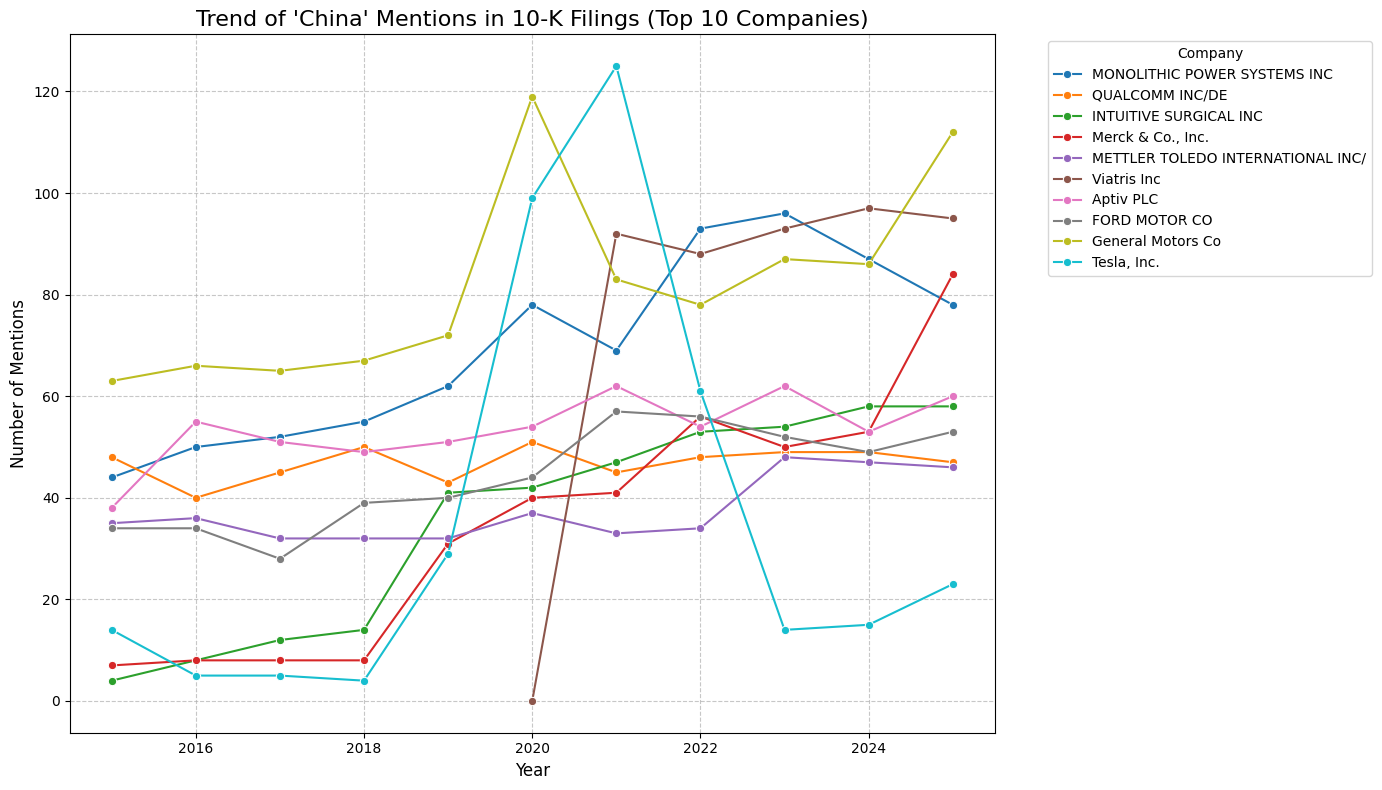

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate total mentions per company to find the top 10
total_mentions = df_all_counts.groupby('Company')['China_Mentions'].sum().sort_values(ascending=False)
top_10_companies = total_mentions.head(10).index.tolist()

print("Top 10 Companies by Total 'China' Mentions (2015-2025):")
print(total_mentions.head(10))

# 2. Filter the main dataframe for these top 10 companies
df_top_10 = df_all_counts[df_all_counts['Company'].isin(top_10_companies)].copy()

# Ensure Year is numeric for proper plotting
df_top_10['Year'] = pd.to_numeric(df_top_10['Year'])

# 3. Plot the trends
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_top_10, x='Year', y='China_Mentions', hue='Company', marker='o')

plt.title("Trend of 'China' Mentions in 10-K Filings (Top 10 Companies)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Mentions", fontsize=12)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Create Pivot Table for all years (2015-2025)
pivot_table_all = df_all_counts.pivot_table(
    index='Company',
    columns='Year',
    values='China_Mentions',
    aggfunc='sum',
    fill_value=0
)

# Calculate total mentions for sorting purposes
pivot_table_all['Total_Mentions'] = pivot_table_all.sum(axis=1)

# Sort by Total Mentions in descending order
pivot_table_all_sorted = pivot_table_all.sort_values(by='Total_Mentions', ascending=False)

# Display the top 10 rows
print("Top 10 Companies by 'China' Mentions (2015-2025) - Pivot Table:")
display(pivot_table_all_sorted.head(10))

Top 10 Companies by 'China' Mentions (2015-2025) - Pivot Table:


Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total_Mentions
Company,,,,,,,,,,,,
General Motors Co,63,66,65,67,72,119,83,78,87,86,112,898
MONOLITHIC POWER SYSTEMS INC,44,50,52,55,62,78,69,93,96,87,78,764
Aptiv PLC,38,55,51,49,51,54,62,54,62,53,60,589
QUALCOMM INC/DE,48,40,45,50,43,51,45,48,49,49,47,515
FORD MOTOR CO,34,34,28,39,40,44,57,56,52,49,53,486
Viatris Inc,0,0,0,0,0,0,92,88,93,97,95,465
METTLER TOLEDO INTERNATIONAL INC/,35,36,32,32,32,37,33,34,48,47,46,412
"Tesla, Inc.",14,5,5,4,29,99,125,61,14,15,23,394
INTUITIVE SURGICAL INC,4,8,12,14,41,42,47,53,54,58,58,391
